# genre

In [0]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window
from pyspark.sql import SparkSession


# Catalog locations
SILVER_PATH = "`mvpde`.`2_silver`"
GOLD_PATH = "`mvpde`.`3_gold`"

# 1. Join Fact, Bridge, and Dimension
genre_counts = (
    spark.table(f"{GOLD_PATH}.fact_film").alias("f")
    .join(spark.table(f"{GOLD_PATH}.bridge_film_genres").alias("b"), "id")
    .join(spark.table(f"{GOLD_PATH}.dim_genres").alias("g"), "genre_id")
    # Option: Filter by primary genre only if you want strictly 100% total movie count
    # .filter(F.col("b.is_primary_genre") == True)
    .groupBy("g.genre_name")
    .agg(F.count("f.id").alias("movie_count"))
)

# 2. Compute percentage share across total movies
window_spec = Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

genre_percentage_df = (
    genre_counts
    .withColumn("total_movies", F.sum("movie_count").over(window_spec))
    .withColumn(
        "percentage", 
        F.round((F.col("movie_count") / F.col("total_movies")) * 100, 2)
    )
    .orderBy(F.col("percentage").desc())
)

# Display PySpark DataFrame result
genre_percentage_df.show(20, truncate=False)



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1155: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------------+-----------+------------+----------+
|genre_name     |movie_count|total_movies|percentage|
+---------------+-----------+------------+----------+
|Drama          |248011     |1148611     |21.59     |
|Documentary    |188617     |1148611     |16.42     |
|Comedy         |151464     |1148611     |13.19     |
|Animation      |64445      |1148611     |5.61      |
|Horror         |58246      |1148611     |5.07      |
|Romance        |57637      |1148611     |5.02      |
|Music          |55032      |1148611     |4.79      |
|Thriller       |49714      |1148611     |4.33      |
|Action         |47930      |1148611     |4.17      |
|Crime          |36039      |1148611     |3.14      |
|Family         |29998      |1148611     |2.61      |
|Adventure      |25749      |1148611     |2.24      |
|TV Movie       |25716      |1148611     |2.24      |
|Fantasy        |25767      |1148611     |2.24      |
|Science Fiction|23237      |1148611     |2.02      |
|Mystery        |22547      

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1155: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

GOLD_PATH = "`mvpde`.`3_gold`"

# 1. Join Fact, Bridge, and Dimension
genre_revenue_df = (
    spark.table(f"{GOLD_PATH}.fact_film").alias("f")
    .join(spark.table(f"{GOLD_PATH}.bridge_film_genres").alias("b"), "id")
    .join(spark.table(f"{GOLD_PATH}.dim_genres").alias("g"), "genre_id")
    # Filter for primary genre to prevent double-counting revenue across multi-genre films
    .filter(F.col("b.is_primary_genre") == True)
    .filter(F.col("f.revenue").isNotNull() & (F.col("f.revenue") > 0))
    .groupBy("g.genre_name")
    .agg(F.sum("f.revenue").alias("total_genre_revenue"))
)

# 2. Compute Market Share Percentage using a Window Function
window_spec = Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

genre_market_share = (
    genre_revenue_df
    .withColumn("total_industry_revenue", F.sum("total_genre_revenue").over(window_spec))
    .withColumn(
        "market_share_pct", 
        F.round((F.col("total_genre_revenue") / F.col("total_industry_revenue")) * 100, 2)
    )
    .orderBy(F.col("total_genre_revenue").desc())
)

# Preview top genres by box office revenue
genre_market_share.show(15, truncate=False)



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1155: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+---------------+-------------------+----------------------+----------------+
|genre_name     |total_genre_revenue|total_industry_revenue|market_share_pct|
+---------------+-------------------+----------------------+----------------+
|Action         |185219303752       |797301153731          |23.23           |
|Comedy         |111642925896       |797301153731          |14.0            |
|Drama          |108976589578       |797301153731          |13.67           |
|Adventure      |105313352826       |797301153731          |13.21           |
|Animation      |60027864632        |797301153731          |7.53            |
|Horror         |37515442644        |797301153731          |4.71            |
|Science Fiction|33889906624        |797301153731          |4.25            |
|Fantasy        |30783854091        |797301153731          |3.86            |
|Family         |28912419238        |797301153731          |3.63            |
|Thriller       |23376603780        |797301153731          |2.93

# historical era

+-----------------------------+-----------+------------+-------------+------------+-------------+-------------+
|film_era                     |movie_count|total_budget|total_revenue|total_profit|avg_movie_roi|portfolio_roi|
+-----------------------------+-----------+------------+-------------+------------+-------------+-------------+
|Digital & Franchise Era      |7112       |170924418144|497316975202 |326392557058|719069.56    |2.91         |
|Blockbuster Era              |2486       |46109432721 |125488808726 |79379376005 |1307.13      |2.72         |
|Streaming & Post-Pandemic Era|3625       |33207633617 |109669887814 |76462254197 |594473.7     |3.3          |
|New Hollywood                |390        |2329231568  |14727326620  |12398095052 |33.63        |6.32         |
|Golden Age of Hollywood      |764        |1692223162  |8551749053   |6859525891  |7.78         |5.05         |
|Silent Era                   |45         |33922130    |110362406    |76440276    |16.85        |3.25   

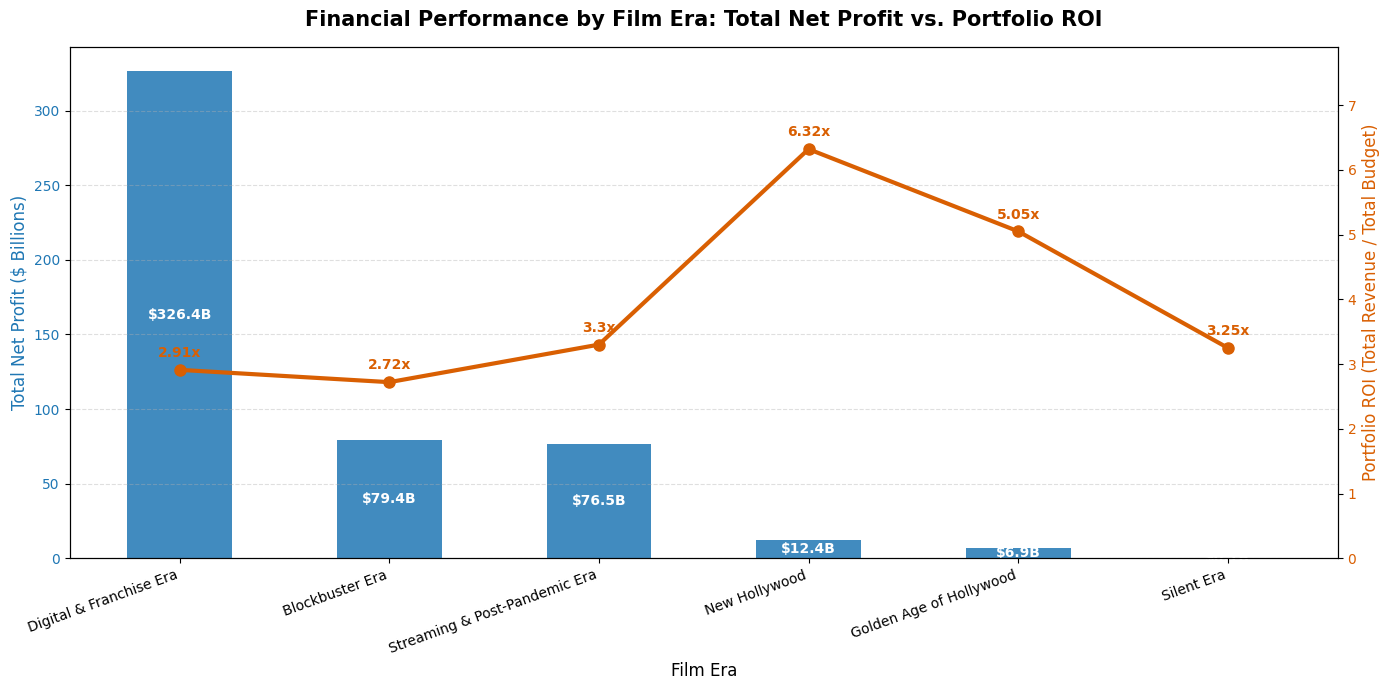

In [0]:



import pyspark.sql.functions as F
import matplotlib.pyplot as plt

GOLD_PATH = "`mvpde`.`3_gold`"

# ==============================================================================
# 1. AGGREGATE EXISTING FACT METRICS BY FILM ERA
# ==============================================================================
# Filter out NULL profits/ROIs (movies with missing financial data)
era_financial_summary = (
    spark.table(f"{GOLD_PATH}.fact_film")
    .filter(F.col("profit").isNotNull() & F.col("roi").isNotNull())
    .groupBy("film_era")
    .agg(
        F.count("id").alias("movie_count"),
        F.sum("budget").alias("total_budget"),
        F.sum("revenue").alias("total_revenue"),
        # Aggregate pre-calculated fact columns directly
        F.sum("profit").alias("total_profit"),
        F.round(F.avg("roi"), 2).alias("avg_movie_roi"),
        # Macro era portfolio return: Total Revenue / Total Budget
        F.round(F.sum("revenue") / F.sum("budget"), 2).alias("portfolio_roi")
    )
    .orderBy(F.col("total_profit").desc())
)

# Display tabular summary in notebook
era_financial_summary.show(truncate=False)

# ==============================================================================
# 2. CONVERT SUMMARY TO PANDAS & PLOT DUAL-AXIS GRAPH (PURE MATPLOTLIB)
# ==============================================================================
pdf = era_financial_summary.toPandas()

# Express profit in Billions for cleaner axis scale
pdf["profit_billions"] = pdf["total_profit"] / 1e9

# Initialize figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis (Left): Net Profit Bars
bars = ax1.bar(
    pdf["film_era"], 
    pdf["profit_billions"], 
    color="#1f77b4", 
    alpha=0.85, 
    width=0.5
)

ax1.set_title("Financial Performance by Film Era: Total Net Profit vs. Portfolio ROI", fontsize=15, fontweight="bold", pad=15)
ax1.set_xlabel("Film Era", fontsize=12)
ax1.set_ylabel("Total Net Profit ($ Billions)", fontsize=12, color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
plt.xticks(rotation=20, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Secondary Axis (Right): Portfolio ROI Line
ax2 = ax1.twinx()
line = ax2.plot(
    pdf["film_era"], 
    pdf["portfolio_roi"], 
    color="#d95f02", 
    marker="o", 
    linewidth=3, 
    markersize=8
)

ax2.set_ylabel("Portfolio ROI (Total Revenue / Total Budget)", fontsize=12, color="#d95f02")
ax2.tick_params(axis="y", labelcolor="#d95f02")

# Annotate bars (Profit) and points (Portfolio ROI)
for i, row in pdf.iterrows():
    # Value inside bar
    ax1.text(
        i, 
        row["profit_billions"] / 2, 
        f"${row['profit_billions']:.1f}B", 
        ha="center", 
        va="center", 
        color="white", 
        fontweight="bold"
    )
    # Value above line marker
    ax2.text(
        i, 
        row["portfolio_roi"] + 0.15, 
        f"{row['portfolio_roi']}x", 
        ha="center", 
        va="bottom", 
        color="#d95f02", 
        fontweight="bold"
    )

# Adjust bounds for clean padding
ax2.set_ylim(0, pdf["portfolio_roi"].max() * 1.25)

plt.tight_layout()
plt.show()



# top 20 films and their people

In [0]:
import pyspark.sql.functions as F

GOLD_PATH = "`mvpde`.`3_gold`"

# ==============================================================================
# 1. EXTRACT DIMENSIONAL ATTRIBUTES VIA CTEs / SUB-QUERIES
# ==============================================================================

# A. Primary Genre (is_primary_genre = True)
primary_genres = (
    spark.table(f"{GOLD_PATH}.bridge_film_genres").alias("bg")
    .join(spark.table(f"{GOLD_PATH}.dim_genres").alias("dg"), "genre_id")
    .filter(F.col("bg.is_primary_genre") == True)
    .select(
        F.col("bg.id"),
        F.col("dg.genre_name").alias("primary_genre")
    )
)

# B. Main Lead Actor (cast_order = 0)
main_actors = (
    spark.table(f"{GOLD_PATH}.bridge_film_cast").alias("bc")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(F.col("bc.cast_order") == 0)
    .select(
        F.col("bc.id"),
        F.col("p.person_name").alias("main_actor")
    )
)

# C. Director (job = 'Director')
directors = (
    spark.table(f"{GOLD_PATH}.bridge_film_crew").alias("bcr")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(F.col("bcr.job") == "Director")
    .groupBy("bcr.id")
    .agg(F.concat_ws(", ", F.collect_set("p.person_name")).alias("director"))
)

# D. Writer (department = 'Writing' or job IN ('Writer', 'Screenplay'))
writers = (
    spark.table(f"{GOLD_PATH}.bridge_film_crew").alias("bcr")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(
        (F.col("bcr.department") == "Writing") | 
        F.col("bcr.job").isin("Writer", "Screenplay", "Author")
    )
    .groupBy("bcr.id")
    .agg(F.concat_ws(", ", F.collect_set("p.person_name")).alias("writer"))
)

# ==============================================================================
# 2. FILTER TOP 20 POPULAR MOVIES & JOIN ENRICHED METADATA
# ==============================================================================

# Filter top 20 by popularity metric
top_20_popular_fact = (
    spark.table(f"{GOLD_PATH}.fact_film")
    .filter(F.col("bayesian_rating").isNotNull())
    .orderBy(F.col("bayesian_rating").desc())
    .limit(20)
)

# Join dimensions and evaluate results
enriched_top_20_df = (
    top_20_popular_fact.alias("f")
    .join(primary_genres, "id", "left")
    .join(main_actors, "id", "left")
    .join(directors, "id", "left")
    .join(writers, "id", "left")
    .select(
        F.col("f.id"),
        F.col("f.title"),
        F.col("f.popularity"),
        F.col("f.vote_average").alias("raw_user_rating"),
        F.col("f.vote_count"),
        F.col("f.bayesian_rating"),
        F.coalesce(F.col("primary_genre"), F.lit("Unassigned")).alias("primary_genre"),
        F.coalesce(F.col("main_actor"), F.lit("Unknown")).alias("main_actor"),
        F.coalesce(F.col("director"), F.lit("Unknown")).alias("director"),
        F.coalesce(F.col("writer"), F.lit("Unknown")).alias("writer")
    )
    # Order output by Bayesian Rating to rank quality within the top 20 popular films
    .orderBy(F.col("bayesian_rating").desc())
)

# Display tabular output
enriched_top_20_df.show(20, truncate=False)



+------+---------------------------------------------------------------------------+----------+---------------+----------+---------------+-------------+----------+--------+-------+
|id    |title                                                                      |popularity|raw_user_rating|vote_count|bayesian_rating|primary_genre|main_actor|director|writer |
+------+---------------------------------------------------------------------------+----------+---------------+----------+---------------+-------------+----------+--------+-------+
|414119|What's New Scooby-Doo? Vol. 3: Halloween Boos and Clues                    |3.724     |9.98           |50        |9.24           |Animation    |Unknown   |Unknown |Unknown|
|392622|What's New, Scooby-Doo? Vol. 7: Ready to Scare                             |2.678     |10.0           |46        |9.2            |Animation    |Unknown   |Unknown |Unknown|
|495686|What's New Scooby-Doo? Vol. 4: Merry Scary Holiday                         |2.092     |

In [0]:
import pyspark.sql.functions as F

GOLD_PATH = "`mvpde`.`3_gold`"

# ==============================================================================
# 1. EXTRACT DIMENSIONAL ATTRIBUTES VIA CTEs / SUB-QUERIES
# ==============================================================================

# A. Primary Genre (is_primary_genre = True)
primary_genres = (
    spark.table(f"{GOLD_PATH}.bridge_film_genres").alias("bg")
    .join(spark.table(f"{GOLD_PATH}.dim_genres").alias("dg"), "genre_id")
    .filter(F.col("bg.is_primary_genre") == True)
    .select(
        F.col("bg.id"),
        F.col("dg.genre_name").alias("primary_genre")
    )
)

# B. Main Lead Actor (cast_order = 0)
main_actors = (
    spark.table(f"{GOLD_PATH}.bridge_film_cast").alias("bc")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(F.col("bc.cast_order") == 0)
    .select(
        F.col("bc.id"),
        F.col("p.person_name").alias("main_actor")
    )
)

# C. Director (job = 'Director')
directors = (
    spark.table(f"{GOLD_PATH}.bridge_film_crew").alias("bcr")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(F.col("bcr.job") == "Director")
    .groupBy("bcr.id")
    .agg(F.concat_ws(", ", F.collect_set("p.person_name")).alias("director"))
)

# D. Writer (department = 'Writing' or job IN ('Writer', 'Screenplay'))
writers = (
    spark.table(f"{GOLD_PATH}.bridge_film_crew").alias("bcr")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(
        (F.col("bcr.department") == "Writing") | 
        F.col("bcr.job").isin("Writer", "Screenplay", "Author")
    )
    .groupBy("bcr.id")
    .agg(F.concat_ws(", ", F.collect_set("p.person_name")).alias("writer"))
)

# ==============================================================================
# 2. FILTER TOP 20 POPULAR MOVIES & JOIN ENRICHED METADATA
# ==============================================================================

# Filter top 20 by popularity metric
top_20_popular_fact = (
    spark.table(f"{GOLD_PATH}.fact_film")
    .filter(F.col("popularity").isNotNull())
    .orderBy(F.col("popularity").desc())
    .limit(20)
)

# Join dimensions and evaluate results
enriched_top_20_df = (
    top_20_popular_fact.alias("f")
    .join(primary_genres, "id", "left")
    .join(main_actors, "id", "left")
    .join(directors, "id", "left")
    .join(writers, "id", "left")
    .select(
        F.col("f.id"),
        F.col("f.title"),
        F.col("f.popularity"),
        F.col("f.vote_average").alias("raw_user_rating"),
        F.col("f.vote_count"),
        F.col("f.bayesian_rating"),
        F.coalesce(F.col("primary_genre"), F.lit("Unassigned")).alias("primary_genre"),
        F.coalesce(F.col("main_actor"), F.lit("Unknown")).alias("main_actor"),
        F.coalesce(F.col("director"), F.lit("Unknown")).alias("director"),
        F.coalesce(F.col("writer"), F.lit("Unknown")).alias("writer")
    )
    # Order output by Bayesian Rating to rank quality within the top 20 popular films
    .orderBy(F.col("bayesian_rating").desc())
)

# Display tabular output
enriched_top_20_df.show(20, truncate=False)



+-------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+---------------+----------+---------------+-------------+----------+--------+-------+
|id     |title                                                                                                                                                              |popularity|raw_user_rating|vote_count|bayesian_rating|primary_genre|main_actor|director|writer |
+-------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------+---------------+----------+---------------+-------------+----------+--------+-------+
|980489 |Gran Turismo                                                                                                                                                       |2680.593  |8.068 

# most popular with team

In [0]:
import pyspark.sql.functions as F

GOLD_PATH = "`mvpde`.`3_gold`"

# ==============================================================================
# 1. PREPARE DIMENSION & BRIDGE AGGREGATIONS
# ==============================================================================

# A. Main Lead Actor (cast_order = 0)
main_actors = (
    spark.table(f"{GOLD_PATH}.bridge_film_cast").alias("bc")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(F.col("bc.cast_order") == 0)
    .select(
        F.col("bc.id"),
        F.col("p.person_name").alias("main_actor")
    )
)

# B. Director (job = 'Director')
directors = (
    spark.table(f"{GOLD_PATH}.bridge_film_crew").alias("bcr")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(F.col("bcr.job") == "Director")
    .groupBy("bcr.id")
    .agg(F.concat_ws(", ", F.collect_set("p.person_name")).alias("director"))
)

# C. Primary Genre
primary_genres = (
    spark.table(f"{GOLD_PATH}.bridge_film_genres").alias("bg")
    .join(spark.table(f"{GOLD_PATH}.dim_genres").alias("dg"), "genre_id")
    .filter(F.col("bg.is_primary_genre") == True)
    .select(
        F.col("bg.id"),
        F.col("dg.genre_name").alias("primary_genre")
    )
)

# D. Writer
writers = (
    spark.table(f"{GOLD_PATH}.bridge_film_crew").alias("bcr")
    .join(spark.table(f"{GOLD_PATH}.dim_people").alias("p"), "person_id")
    .filter(
        (F.col("bcr.department") == "Writing") | 
        F.col("bcr.job").isin("Writer", "Screenplay", "Author")
    )
    .groupBy("bcr.id")
    .agg(F.concat_ws(", ", F.collect_set("p.person_name")).alias("writer"))
)

# ==============================================================================
# 2. INNER JOIN FACT WITH CAST & DIRECTOR, THEN RANK TOP 20 BY POPULARITY
# ==============================================================================

top_20_popular_with_cast_and_director = (
    spark.table(f"{GOLD_PATH}.fact_film").alias("f")
    # INNER JOINs enforce that BOTH cast and director must exist
    .join(main_actors, "id", "inner")
    .join(directors, "id", "inner")
    # LEFT JOINs keep primary genre and writer optional if available
    .join(primary_genres, "id", "left")
    .join(writers, "id", "left")
    .select(
        F.col("f.id"),
        F.col("f.title"),
        F.col("f.popularity"),
        F.col("f.bayesian_rating"),
        F.col("main_actor"),
        F.col("director"),
        F.coalesce(F.col("primary_genre"), F.lit("Unassigned")).alias("primary_genre"),
        F.coalesce(F.col("writer"), F.lit("Unknown")).alias("writer")
    )
    .filter(F.col("f.popularity").isNotNull())
    .orderBy(F.col("f.popularity").desc())
    .limit(20)
)

# Display result table
top_20_popular_with_cast_and_director.show(20, truncate=False)



+------+--------------------------------------------------------------+----------+---------------+-------------------+--------------------+-------------+----------------------------------------------------------------------------------------+
|id    |title                                                         |popularity|bayesian_rating|main_actor         |director            |primary_genre|writer                                                                                  |
+------+--------------------------------------------------------------+----------+---------------+-------------------+--------------------+-------------+----------------------------------------------------------------------------------------+
|1880  |Red Dawn                                                      |300.738   |6.24           |Patrick Swayze     |John Milius         |Action       |Kevin Reynolds, John Milius                                                             |
|156022|The Equalizer       

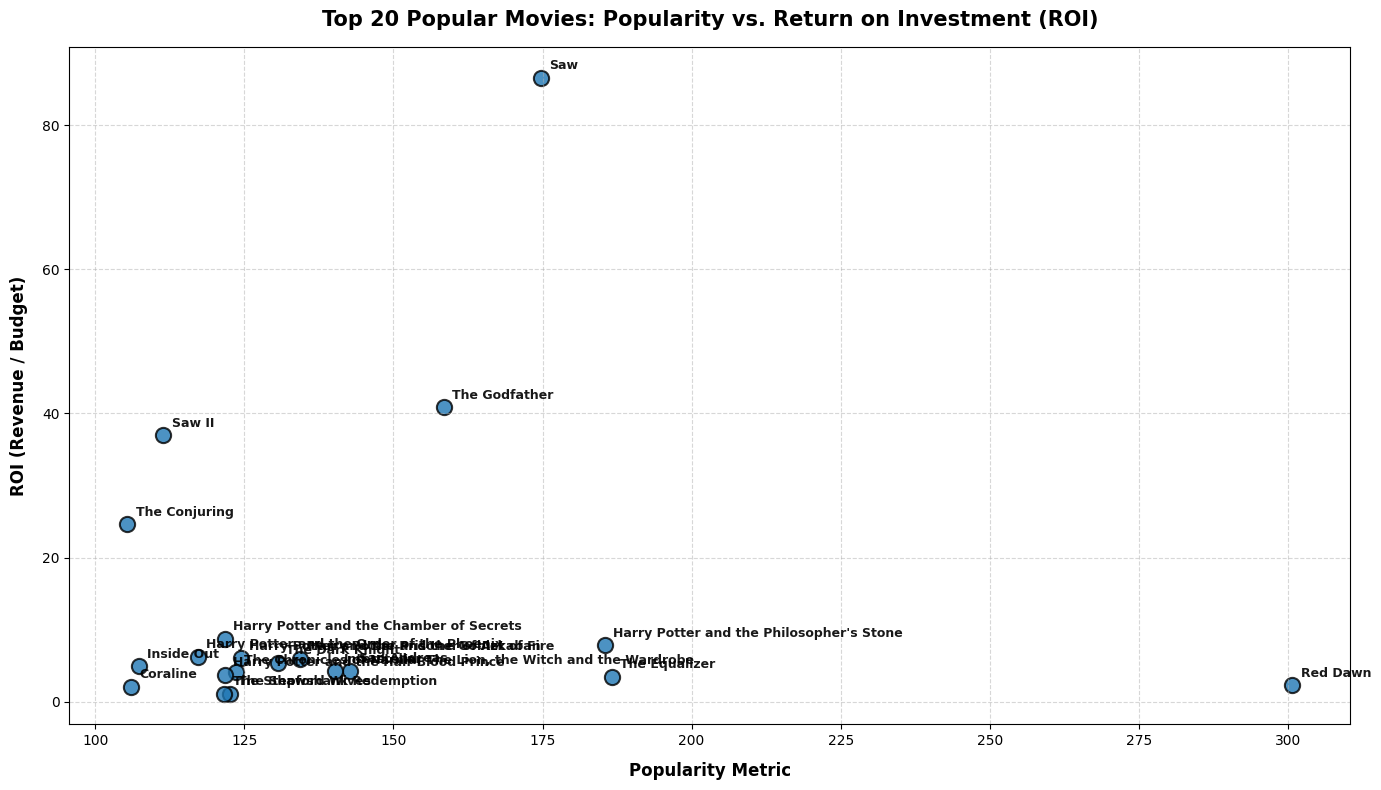

In [0]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

GOLD_PATH = "`mvpde`.`3_gold`"

# ==============================================================================
# 1. FETCH TOP 20 POPULAR MOVIES WITH CAST & DIRECTOR (INCLUDING POPULARITY & ROI)
# ==============================================================================
top_20_popular_df = (
    spark.table(f"{GOLD_PATH}.fact_film").alias("f")
    # Inner joins enforce the presence of cast and director metadata
    .join(
        spark.table(f"{GOLD_PATH}.bridge_film_cast")
        .filter(F.col("cast_order") == 0),
        "id", "inner"
    )
    .join(
        spark.table(f"{GOLD_PATH}.bridge_film_crew")
        .filter(F.col("job") == "Director"),
        "id", "inner"
    )
    # Ensure valid ROI (non-null and budget > 0)
    .filter(F.col("f.popularity").isNotNull() & F.col("f.roi").isNotNull())
    .select(
        F.col("f.id"),
        F.col("f.title"),
        F.col("f.popularity"),
        F.col("f.roi")
    )
    .dropDuplicates(["id"])
    .orderBy(F.col("f.popularity").desc())
    .limit(20)
)

# Convert aggregated sample to Pandas
pdf = top_20_popular_df.toPandas()

# ==============================================================================
# 2. PLOT POPULARITY VS. ROI IN MATPLOTLIB
# ==============================================================================
plt.figure(figsize=(14, 8))

# Draw scatter points
plt.scatter(
    pdf["popularity"], 
    pdf["roi"], 
    color="#1f77b4", 
    s=120, 
    alpha=0.8, 
    edgecolors="black", 
    linewidth=1.5
)

# Title & axis labels
plt.title("Top 20 Popular Movies: Popularity vs. Return on Investment (ROI)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Popularity Metric", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("ROI (Revenue / Budget)", fontsize=12, fontweight="bold", labelpad=10)
plt.grid(True, linestyle="--", alpha=0.5)

# Annotate each point with the corresponding movie title
for idx, row in pdf.iterrows():
    plt.annotate(
        row["title"],
        (row["popularity"], row["roi"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="semibold",
        alpha=0.9
    )

plt.tight_layout()
plt.show()



In [0]:
import pyspark.sql.functions as F

GOLD_PATH = "`mvpde`.`3_gold`"

# Load Gold Dimension, Bridge, and Fact tables
dim_people = spark.table(f"{GOLD_PATH}.dim_people")
bridge_cast = spark.table(f"{GOLD_PATH}.bridge_film_cast")
bridge_crew = spark.table(f"{GOLD_PATH}.bridge_film_crew")
fact_movies = spark.table(f"{GOLD_PATH}.fact_film")

# ==============================================================================
# 1. TOP 5 PROLIFIC ACTORS
# ==============================================================================
top_5_actors = (
    bridge_cast.alias("bc")
    # Inner join to ensure only valid movies in Gold Fact are counted
    .join(fact_movies.alias("f"), "id", "inner")
    .join(dim_people.alias("p"), "person_id", "inner")
    .groupBy("p.person_id", "p.person_name")
    .agg(
        F.countDistinct("bc.id").alias("movie_count"),
        F.round(F.avg("f.bayesian_rating"), 2).alias("avg_movie_rating")
    )
    .orderBy(F.col("movie_count").desc(), F.col("avg_movie_rating").desc())
    .limit(5)
)

print("=== TOP 5 MOST PROLIFIC ACTORS ===")
top_5_actors.show(truncate=False)

# ==============================================================================
# 2. TOP 5 PROLIFIC DIRECTORS
# ==============================================================================
top_5_directors = (
    bridge_crew.alias("bcr")
    .join(fact_movies.alias("f"), "id", "inner")
    .join(dim_people.alias("p"), "person_id", "inner")
    .filter(F.col("bcr.job") == "Director")
    .groupBy("p.person_id", "p.person_name")
    .agg(
        F.countDistinct("bcr.id").alias("movie_count"),
        F.round(F.avg("f.bayesian_rating"), 2).alias("avg_movie_rating")
    )
    .orderBy(F.col("movie_count").desc(), F.col("avg_movie_rating").desc())
    .limit(5)
)

print("=== TOP 5 MOST PROLIFIC DIRECTORS ===")
top_5_directors.show(truncate=False)

# ==============================================================================
# 3. TOP 5 PROLIFIC WRITERS
# ==============================================================================
top_5_writers = (
    bridge_crew.alias("bcr")
    .join(fact_movies.alias("f"), "id", "inner")
    .join(dim_people.alias("p"), "person_id", "inner")
    .filter(
        (F.col("bcr.department") == "Writing") | 
        F.col("bcr.job").isin("Writer", "Screenplay", "Author")
    )
    .groupBy("p.person_id", "p.person_name")
    .agg(
        F.countDistinct("bcr.id").alias("movie_count"),
        F.round(F.avg("f.bayesian_rating"), 2).alias("avg_movie_rating")
    )
    .orderBy(F.col("movie_count").desc(), F.col("avg_movie_rating").desc())
    .limit(5)
)

print("=== TOP 5 MOST PROLIFIC WRITERS ===")
top_5_writers.show(truncate=False)



=== TOP 5 MOST PROLIFIC ACTORS ===
+---------+-----------------+-----------+----------------+
|person_id|person_name      |movie_count|avg_movie_rating|
+---------+-----------------+-----------+----------------+
|2231     |Samuel L. Jackson|67         |6.6             |
|380      |Robert De Niro   |57         |6.61            |
|62       |Bruce Willis     |51         |6.44            |
|1892     |Matt Damon       |48         |6.8             |
|192      |Morgan Freeman   |46         |6.76            |
+---------+-----------------+-----------+----------------+

=== TOP 5 MOST PROLIFIC DIRECTORS ===
+---------+----------------+-----------+----------------+
|person_id|person_name     |movie_count|avg_movie_rating|
+---------+----------------+-----------+----------------+
|488      |Steven Spielberg|27         |7.2             |
|1243     |Woody Allen     |22         |6.69            |
|1032     |Martin Scorsese |21         |7.35            |
|190      |Clint Eastwood  |20         |7.03   

In [0]:
import pyspark.sql.functions as F

GOLD_PATH = "`mvpde`.`3_gold`"

# ==============================================================================
# 1. EXTRACT PRIMARY GENRE
# ==============================================================================
primary_genres = (
    spark.table(f"{GOLD_PATH}.bridge_film_genres").alias("bg")
    .join(spark.table(f"{GOLD_PATH}.dim_genres").alias("dg"), "genre_id")
    .filter(F.col("bg.is_primary_genre") == True)
    .select(
        F.col("bg.id"),
        F.col("dg.genre_name").alias("primary_genre")
    )
)

# ==============================================================================
# 2. QUERY LEAST PROFITABLE MOVIES & JOIN METADATA
# ==============================================================================
least_profitable_movies = (
    spark.table(f"{GOLD_PATH}.fact_film").alias("f")
    # Filter for movies with confirmed financial data
    .filter(
        F.col("f.budget").isNotNull() & (F.col("f.budget") > 0) &
        F.col("f.revenue").isNotNull() & (F.col("f.revenue") > 0) &
        F.col("f.profit").isNotNull()
    )
    .join(primary_genres, "id", "left")
    .select(
        F.col("f.id"),
        F.col("f.title"),
        F.col("f.release_year"),
        F.col("f.budget"),
        F.col("f.revenue"),
        F.col("f.profit"),
        F.col("f.roi"),
        F.coalesce(F.col("primary_genre"), F.lit("Unassigned")).alias("primary_genre"),
        F.coalesce(F.col("f.primary_production_company"), F.lit("Unknown")).alias("primary_producer")
    )
    .orderBy(F.col("f.profit").asc())  # Ascending order yields biggest negative net profits
    .limit(20)
)

# Display tabular output
least_profitable_movies.show(20, truncate=False)



+-------+----------------------------------------------------+------------+---------+---------+----------+----+-------------+---------------------+
|id     |title                                               |release_year|budget   |revenue  |profit    |roi |primary_genre|primary_producer     |
+-------+----------------------------------------------------+------------+---------+---------+----------+----+-------------+---------------------+
|1756546|Batman v Superman: Dawn of Justice: Ultimate Edition|2016        |874362803|250000000|-624362803|0.29|Unassigned   |Unknown              |
|1449031|moose movie 2                                       |1972        |470000000|1        |-469999999|0.0 |History      |Unknown              |
|1453985|Diggy and The Bandits                               |2001        |447000000|12       |-446999988|0.0 |Crime        |Bartholomew Compppp  |
|1453767|Diggy and The Bandits                               |2001        |447000000|12       |-446999988|0.0 |C

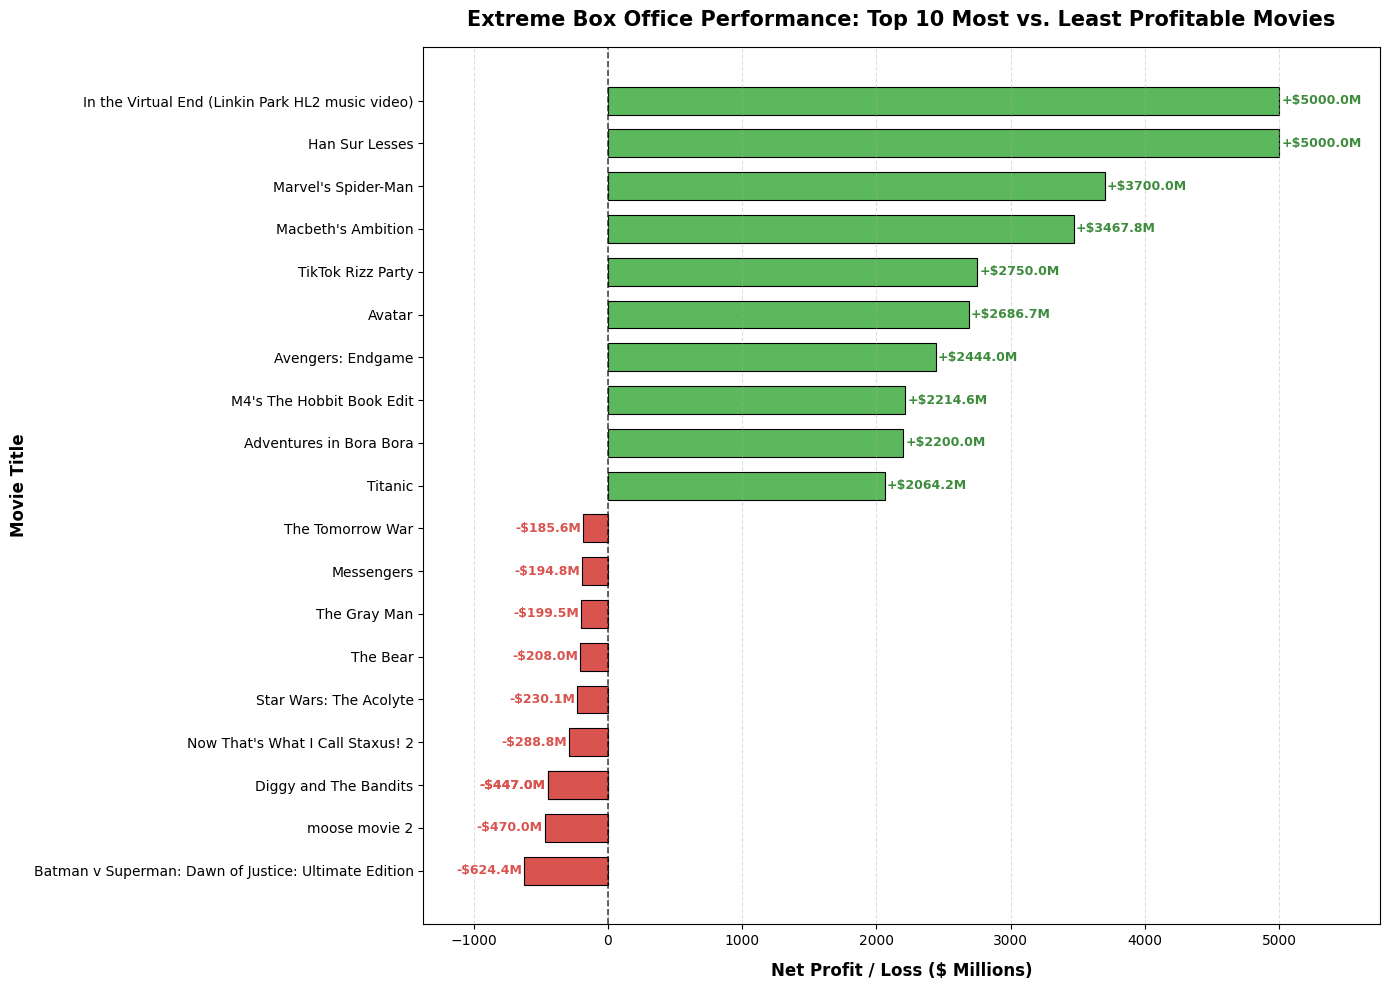

In [0]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import pandas as pd

GOLD_PATH = "`mvpde`.`3_gold`"

# ==============================================================================
# 1. FETCH TOP 10 MOST AND LEAST PROFITABLE MOVIES
# ==============================================================================

# Base filtered DataFrame ensuring valid financial figures
valid_financials = (
    spark.table(f"{GOLD_PATH}.fact_film")
    .filter(
        F.col("budget").isNotNull() & (F.col("budget") > 0) &
        F.col("revenue").isNotNull() & (F.col("revenue") > 0) &
        F.col("profit").isNotNull()
    )
    .select("id", "title", "profit")
)

# Top 10 Most Profitable
top_10_most = (
    valid_financials
    .orderBy(F.col("profit").desc())
    .limit(10)
    .withColumn("category", F.lit("Most Profitable"))
)

# Top 10 Least Profitable (Biggest Losses)
top_10_least = (
    valid_financials
    .orderBy(F.col("profit").asc())
    .limit(10)
    .withColumn("category", F.lit("Least Profitable"))
)

# Union both datasets and convert to Pandas for visualization
combined_df = top_10_most.union(top_10_least)
pdf = combined_df.toPandas()

# Convert profit to Millions for clean display
pdf["profit_millions"] = pdf["profit"] / 1e6

# Sort ascending by profit so the highest values plot at the top of horizontal chart
pdf = pdf.sort_values(by="profit_millions", ascending=True)

# ==============================================================================
# 2. RENDER HORIZONTAL DIVERGING BAR CHART
# ==============================================================================

plt.figure(figsize=(14, 10))

# Color bars conditionally: Green for positive profit, Red for losses
colors = ["#d9534f" if val < 0 else "#5cb85c" for val in pdf["profit_millions"]]

bars = plt.barh(
    pdf["title"], 
    pdf["profit_millions"], 
    color=colors, 
    edgecolor="black", 
    linewidth=0.8,
    height=0.65
)

# Vertical baseline at $0 Profit/Loss
plt.axvline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

# Formatting Labels & Title
plt.title("Extreme Box Office Performance: Top 10 Most vs. Least Profitable Movies", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Net Profit / Loss ($ Millions)", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Movie Title", fontsize=12, fontweight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Annotate values on individual bars
for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    
    if width < 0:
        # Place label to the left of negative bars
        plt.text(width - 15, y_pos, f"-${abs(width):.1f}M", va="center", ha="right", fontsize=9, fontweight="bold", color="#d9534f")
    else:
        # Place label to the right of positive bars
        plt.text(width + 15, y_pos, f"+${width:.1f}M", va="center", ha="left", fontsize=9, fontweight="bold", color="#3d8b3d")

# Padding bounds
margin = max(abs(pdf["profit_millions"].min()), pdf["profit_millions"].max()) * 0.15
plt.xlim(pdf["profit_millions"].min() - margin, pdf["profit_millions"].max() + margin)

plt.tight_layout()
plt.show()



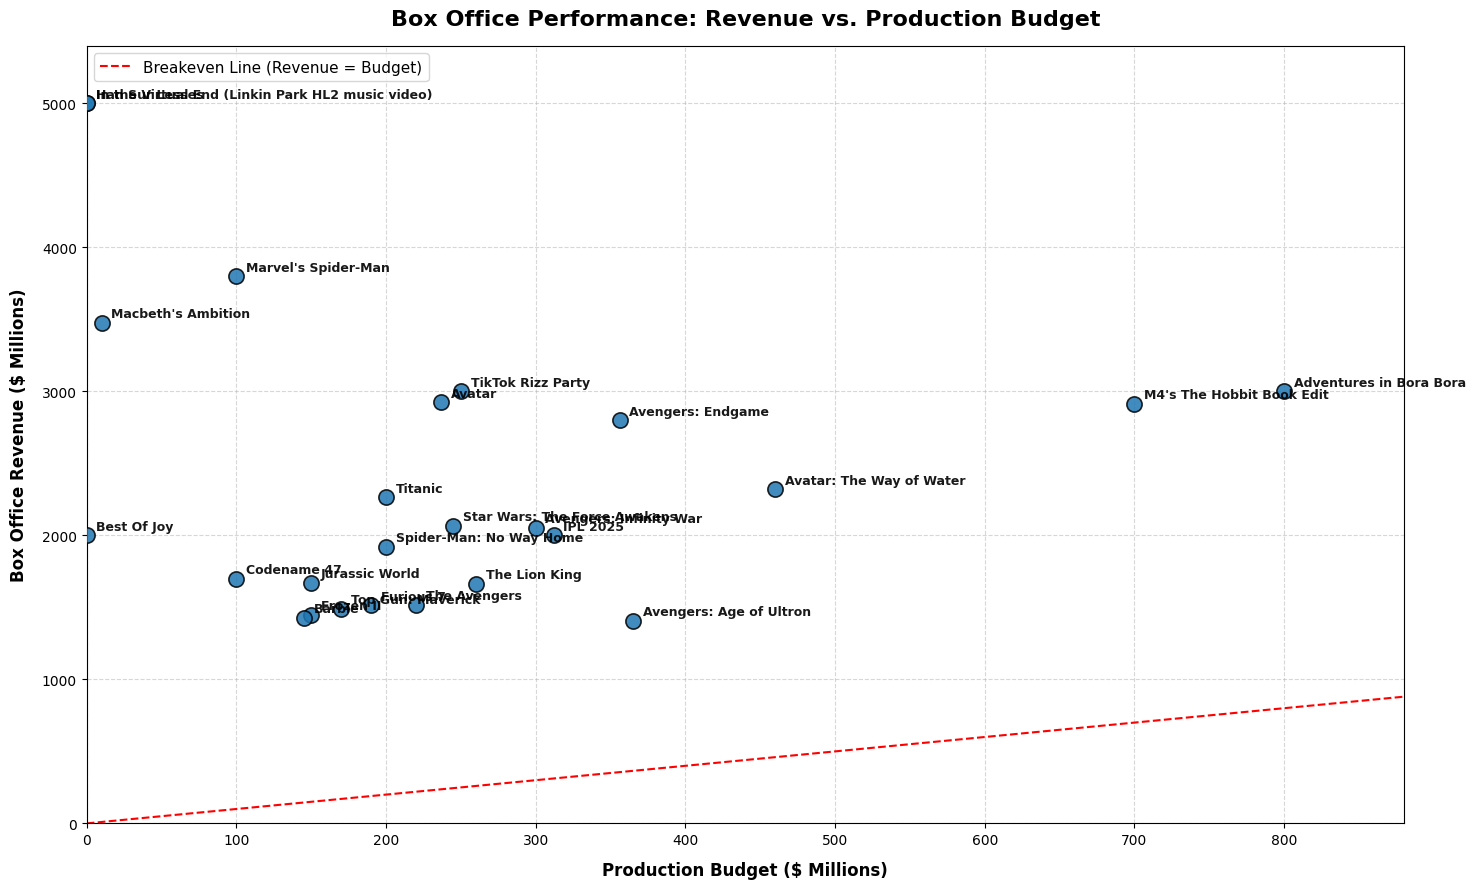

In [0]:
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

GOLD_PATH = "`mvpde`.`3_gold`"

# ==============================================================================
# 1. QUERY TOP MOVIES WITH VALID BUDGET & REVENUE FIGURES
# ==============================================================================
# Filter out missing/sentinel zero financial entries
financial_sample_df = (
    spark.table(f"{GOLD_PATH}.fact_film")
    .filter(
        F.col("budget").isNotNull() & (F.col("budget") > 0) &
        F.col("revenue").isNotNull() & (F.col("revenue") > 0)
    )
    .select("id", "title", "budget", "revenue")
    .orderBy(F.col("revenue").desc())
    .limit(25)  # Limit to 25 titles to keep point labels readable
)

# Convert summary to Pandas
pdf = financial_sample_df.toPandas()

# Convert financial metrics to Millions ($M) for readable axes
pdf["budget_millions"] = pdf["budget"] / 1e6
pdf["revenue_millions"] = pdf["revenue"] / 1e6

# ==============================================================================
# 2. PLOT REVENUE VS. BUDGET SCATTER CHART
# ==============================================================================
plt.figure(figsize=(15, 9))

# Scatter points
scatter = plt.scatter(
    pdf["budget_millions"], 
    pdf["revenue_millions"], 
    color="#1f77b4", 
    s=120, 
    alpha=0.85, 
    edgecolors="black", 
    linewidth=1.2,
    zorder=3
)

# Draw Breakeven Line (Y = X)
max_val = max(pdf["budget_millions"].max(), pdf["revenue_millions"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", linewidth=1.5, label="Breakeven Line (Revenue = Budget)", zorder=2)

# Formatting Labels and Title
plt.title("Box Office Performance: Revenue vs. Production Budget", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Production Budget ($ Millions)", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Box Office Revenue ($ Millions)", fontsize=12, fontweight="bold", labelpad=10)
plt.grid(True, linestyle="--", alpha=0.5, zorder=1)
plt.legend(loc="upper left", fontsize=11)

# Annotate each scatter point with the movie title
for idx, row in pdf.iterrows():
    plt.annotate(
        row["title"],
        (row["budget_millions"], row["revenue_millions"]),
        xytext=(7, 4),
        textcoords="offset points",
        fontsize=9,
        fontweight="semibold",
        alpha=0.9
    )

# Padding axis limits
plt.xlim(0, pdf["budget_millions"].max() * 1.1)
plt.ylim(0, pdf["revenue_millions"].max() * 1.08)

plt.tight_layout()
plt.show()

